<a href="https://colab.research.google.com/github/celinekm/CN/blob/main/anima%C3%A7%C3%A3ogauss_celine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NOME: CELINE KAZUMI MIYAJIMA RA: 176209

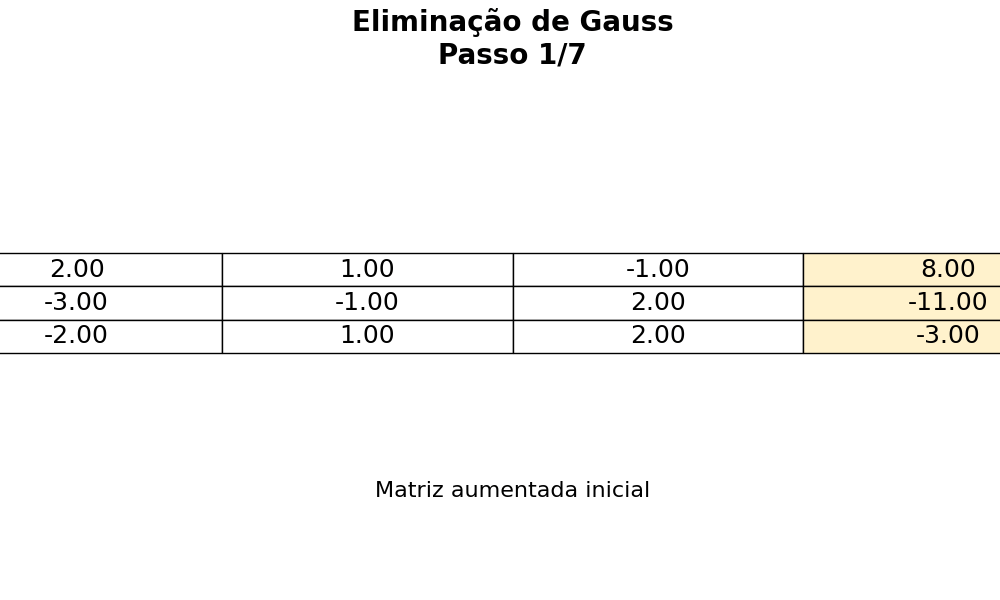

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image


# ============================================================
# 1. MATRIZ
# ============================================================

# ALTERE A MATRIZ AQUI
M = np.array([
    [ 2,  1, -1,   8],
    [-3, -1,  2, -11],
    [-2,  1,  2,  -3]
], dtype=float)


# Velocidade do GIF
FPS = 1


# ============================================================
# 2. ELIMINAÇÃO DE GAUSS
# ============================================================

def gauss_passos(M, tol=1e-12):

    A = M.copy().astype(float)

    n = A.shape[0]

    passos = []

    # Estado inicial
    passos.append({
        "matriz": A.copy(),
        "texto": "Matriz aumentada inicial",
        "pivo": None,
        "linha": None,
        "coluna": None
    })

    for k in range(n - 1):

        # ----------------------------------------------------
        # Pivoteamento parcial
        # ----------------------------------------------------

        linha_pivo = k + np.argmax(
            np.abs(A[k:, k])
        )

        if abs(A[linha_pivo, k]) < tol:
            continue

        # Troca de linhas
        if linha_pivo != k:

            A[[k, linha_pivo]] = A[[linha_pivo, k]]

            passos.append({
                "matriz": A.copy(),
                "texto": f"R{k+1} ↔ R{linha_pivo+1}",
                "pivo": A[k, k],
                "linha": None,
                "coluna": k
            })

        # ----------------------------------------------------
        # Eliminação
        # ----------------------------------------------------

        for i in range(k + 1, n):

            if abs(A[i, k]) < tol:
                continue

            multiplicador = A[i, k] / A[k, k]

            A[i, :] = (
                A[i, :]
                - multiplicador * A[k, :]
            )

            # Corrige erros numéricos
            A[np.abs(A) < tol] = 0

            passos.append({
                "matriz": A.copy(),
                "texto": (
                    f"R{i+1} ← R{i+1} "
                    f"− ({multiplicador:.3f}) R{k+1}"
                ),
                "pivo": A[k, k],
                "linha": i,
                "coluna": k
            })

    # Estado final
    passos.append({
        "matriz": A.copy(),
        "texto": "Forma triangular superior",
        "pivo": None,
        "linha": None,
        "coluna": None
    })

    return passos


passos = gauss_passos(M)


# ============================================================
# 3. FUNÇÃO PARA DESENHAR A MATRIZ
# ============================================================

def desenhar_matriz(ax, matriz, passo, numero):

    ax.clear()
    ax.axis("off")

    n, m = matriz.shape

    # --------------------------------------------------------
    # Tabela
    # --------------------------------------------------------

    tabela = ax.table(
        cellText=[
            [
                f"{matriz[i, j]:.2f}"
                for j in range(m)
            ]
            for i in range(n)
        ],
        cellLoc="center",
        loc="center"
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(18)
    tabela.scale(1.5, 2.0)

    # --------------------------------------------------------
    # Coluna b
    # --------------------------------------------------------

    for i in range(n):

        tabela[
            (i, m - 1)
        ].set_facecolor("#FFF2CC")

    # --------------------------------------------------------
    # Destaca pivô
    # --------------------------------------------------------

    if passo["pivo"] is not None:

        linha_pivo = passo["coluna"]
        coluna_pivo = passo["coluna"]

        if linha_pivo < n:

            tabela[
                (linha_pivo, coluna_pivo)
            ].set_facecolor("#90EE90")

    # --------------------------------------------------------
    # Destaca linha que está sendo alterada
    # --------------------------------------------------------

    if passo["linha"] is not None:

        linha = passo["linha"]

        for j in range(m):

            if j != passo["coluna"]:

                tabela[
                    (linha, j)
                ].set_facecolor("#D9EAF7")

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    ax.set_title(
        f"Eliminação de Gauss\n"
        f"Passo {numero + 1}/{len(passos)}",
        fontsize=20,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Operação
    # --------------------------------------------------------

    ax.text(
        0.5,
        0.08,
        passo["texto"],
        transform=ax.transAxes,
        ha="center",
        fontsize=16
    )


# ============================================================
# 4. CRIAÇÃO DA ANIMAÇÃO
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


def atualizar(frame):

    desenhar_matriz(
        ax,
        passos[frame]["matriz"],
        passos[frame],
        frame
    )


animacao = FuncAnimation(
    fig,
    atualizar,
    frames=len(passos),
    interval=1000 / FPS,
    repeat=True
)


# ============================================================
# 5. SALVA E MOSTRA O GIF NA SAÍDA
# ============================================================

NOME_GIF = "eliminacao_gauss.gif"

animacao.save(
    NOME_GIF,
    writer=PillowWriter(fps=FPS)
)

plt.close(fig)

# Exibe diretamente no output do Colab
display(
    Image(
        filename=NOME_GIF
    )
)
